In [4]:
!pip install ultralytics


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 21.0 MB/s eta 0:00:00


In [15]:
# CELL: Create custom_blocks.py directly in Colab
custom_blocks_code = '''
import torch.nn as nn

class ConvBnAct(nn.Module):
    def __init__(self, c_in, c_out, k=1, s=1, p=0, g=1, act=True):
        super().__init__()
        self.conv = nn.Conv2d(c_in, c_out, k, stride=s, padding=p, groups=g, bias=False)
        self.bn   = nn.BatchNorm2d(c_out)
        self.act  = nn.SiLU() if act else nn.Identity()
    def forward(self, x):
        return self.act(self.bn(self.conv(x)))

class MobileViTBlock(nn.Module):
    def __init__(self, c1, c2=None, depth=1):
        super().__init__()
        c   = c1
        mid = min(max(c * 2, 32), 512)
        layers = []
        for _ in range(max(1, depth)):
            layers.append(nn.Sequential(
                ConvBnAct(c, c,   k=3, p=1, g=c),
                ConvBnAct(c, mid, k=1),
                ConvBnAct(mid, mid, k=5, p=2, g=mid),
                ConvBnAct(mid, c, k=1, act=False),
                nn.BatchNorm2d(c),
            ))
        self.blocks = nn.ModuleList(layers)
        self.act    = nn.SiLU()
    def forward(self, x):
        for blk in self.blocks:
            x = self.act(x + blk(x))
        return x

class SEBlock(nn.Module):
    def __init__(self, c1, c2=None, r=16):
        super().__init__()
        c  = c1
        rd = max(1, c // r)
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc   = nn.Sequential(
            nn.Linear(c, rd, bias=False), nn.ReLU(inplace=True),
            nn.Linear(rd, c,  bias=False), nn.Sigmoid(),
        )
    def forward(self, x):
        b, c, _, _ = x.shape
        return x * self.fc(self.pool(x).view(b, c)).view(b, c, 1, 1)
'''

# Write to /tmp so it's always accessible in this session
with open('/tmp/custom_blocks.py', 'w') as f:
    f.write(custom_blocks_code)

print("✅ custom_blocks.py created at /tmp/custom_blocks.py")

✅ custom_blocks.py created at /tmp/custom_blocks.py


In [16]:
import sys
sys.path.insert(0, '/tmp')  # point to /tmp, not Drive

import custom_blocks

import ultralytics.nn.modules as ulmods
ulmods.MobileViTBlock = custom_blocks.MobileViTBlock
ulmods.SEBlock        = custom_blocks.SEBlock
ulmods.ConvBnAct      = custom_blocks.ConvBnAct

from ultralytics import YOLO
model = YOLO(BEST_MODEL_PATH)
print("✅ Model loaded!")

✅ Model loaded!


🎯 YOLO MODEL - COMPLETE ANALYSIS

📊 PART 1: TRAINING HISTORY CURVES
✅ Loaded 60 epochs from results CSV

Training Metrics per Epoch:
----------------------------------------------------------------------------------------------------
Epoch    Train Loss      Val Loss        mAP@0.5         mAP@0.5:0.95    Precision       Recall         
----------------------------------------------------------------------------------------------------
1        1.9625          1.3361          0.3904          0.2586          0.3066          0.6315         
2        1.3294          1.0848          0.4792          0.3206          0.3892          0.8142         
3        1.1648          0.9601          0.5911          0.4399          0.3968          0.8306         
4        1.0635          0.8337          0.7602          0.5952          0.5376          0.8815         
5        1.0005          0.8217          0.8694          0.6849          0.6916          0.8778         
6        0.9490          0.7574    

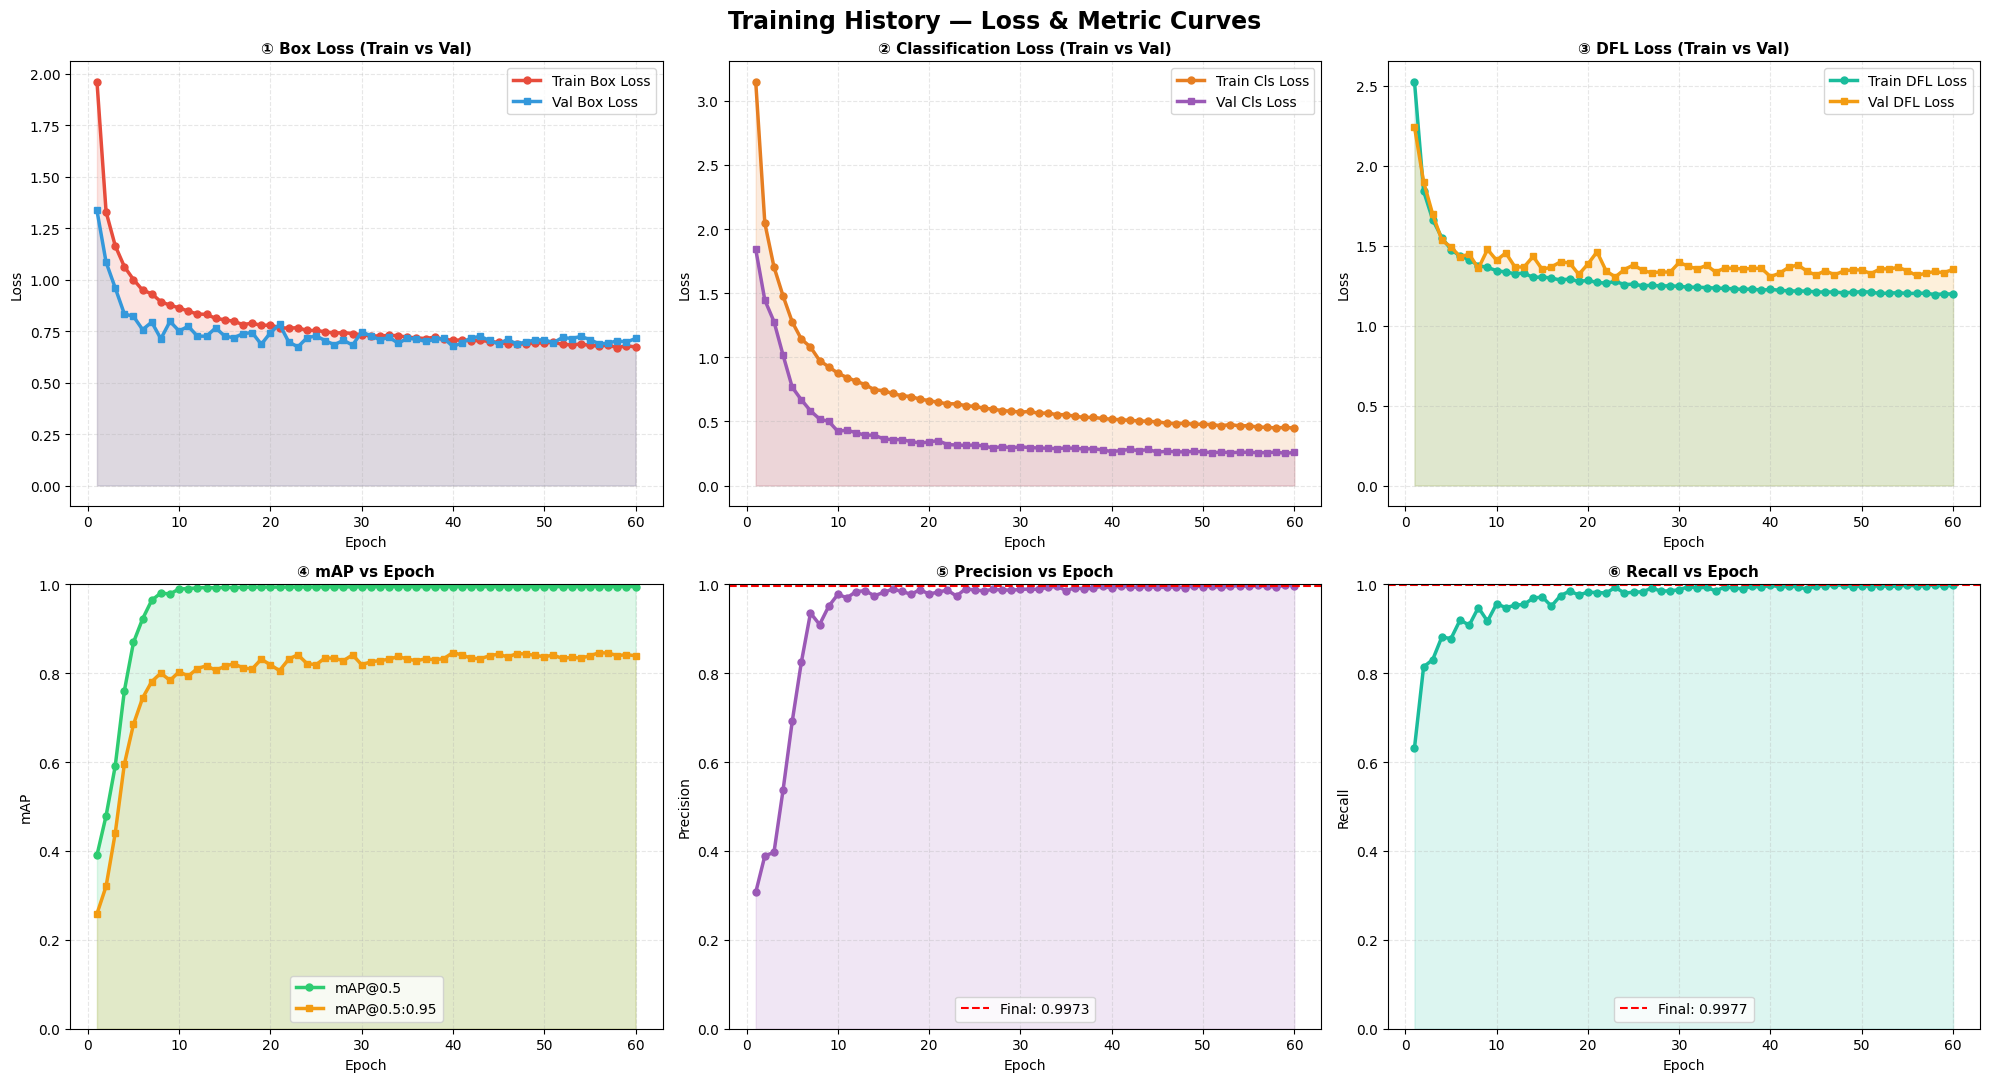

✅ Training curves saved!

📦 PART 2: LOADING MODEL
✅ Using pre-loaded model with custom_blocks registered.

🧪 PART 3: TEST SET EVALUATION
Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cpu CPU (AMD EPYC 7B12)
custom_model summary: 110 layers, 3,159,918 parameters, 0 gradients, 8.6 GFLOPs
val: Fast image access ✅ (ping: 0.8±0.2 ms, read: 40.5±83.4 MB/s, size: 659.9 KB)
val: Scanning /content/drive/.shortcut-targets-by-id/1BIXr598Of-KAXVBXPFaQfWNojzVat0vC/10_class/labels/test.cache... 1945 images, 0 backgrounds, 1 corrupt: 100% ━━━━━━━━━━━━ 1945/1945 582.7Mit/s 0.0s
val: /content/drive/.shortcut-targets-by-id/1BIXr598Of-KAXVBXPFaQfWNojzVat0vC/10_class/images/test/Slippery_Road_0122.jpg: ignoring corrupt image/label: non-normalized or out of bounds coordinates [     2.3184      4.8788      1.9435      2.0124]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 122/122 3.7s/it 7:32
                   all       1944       1944      0.

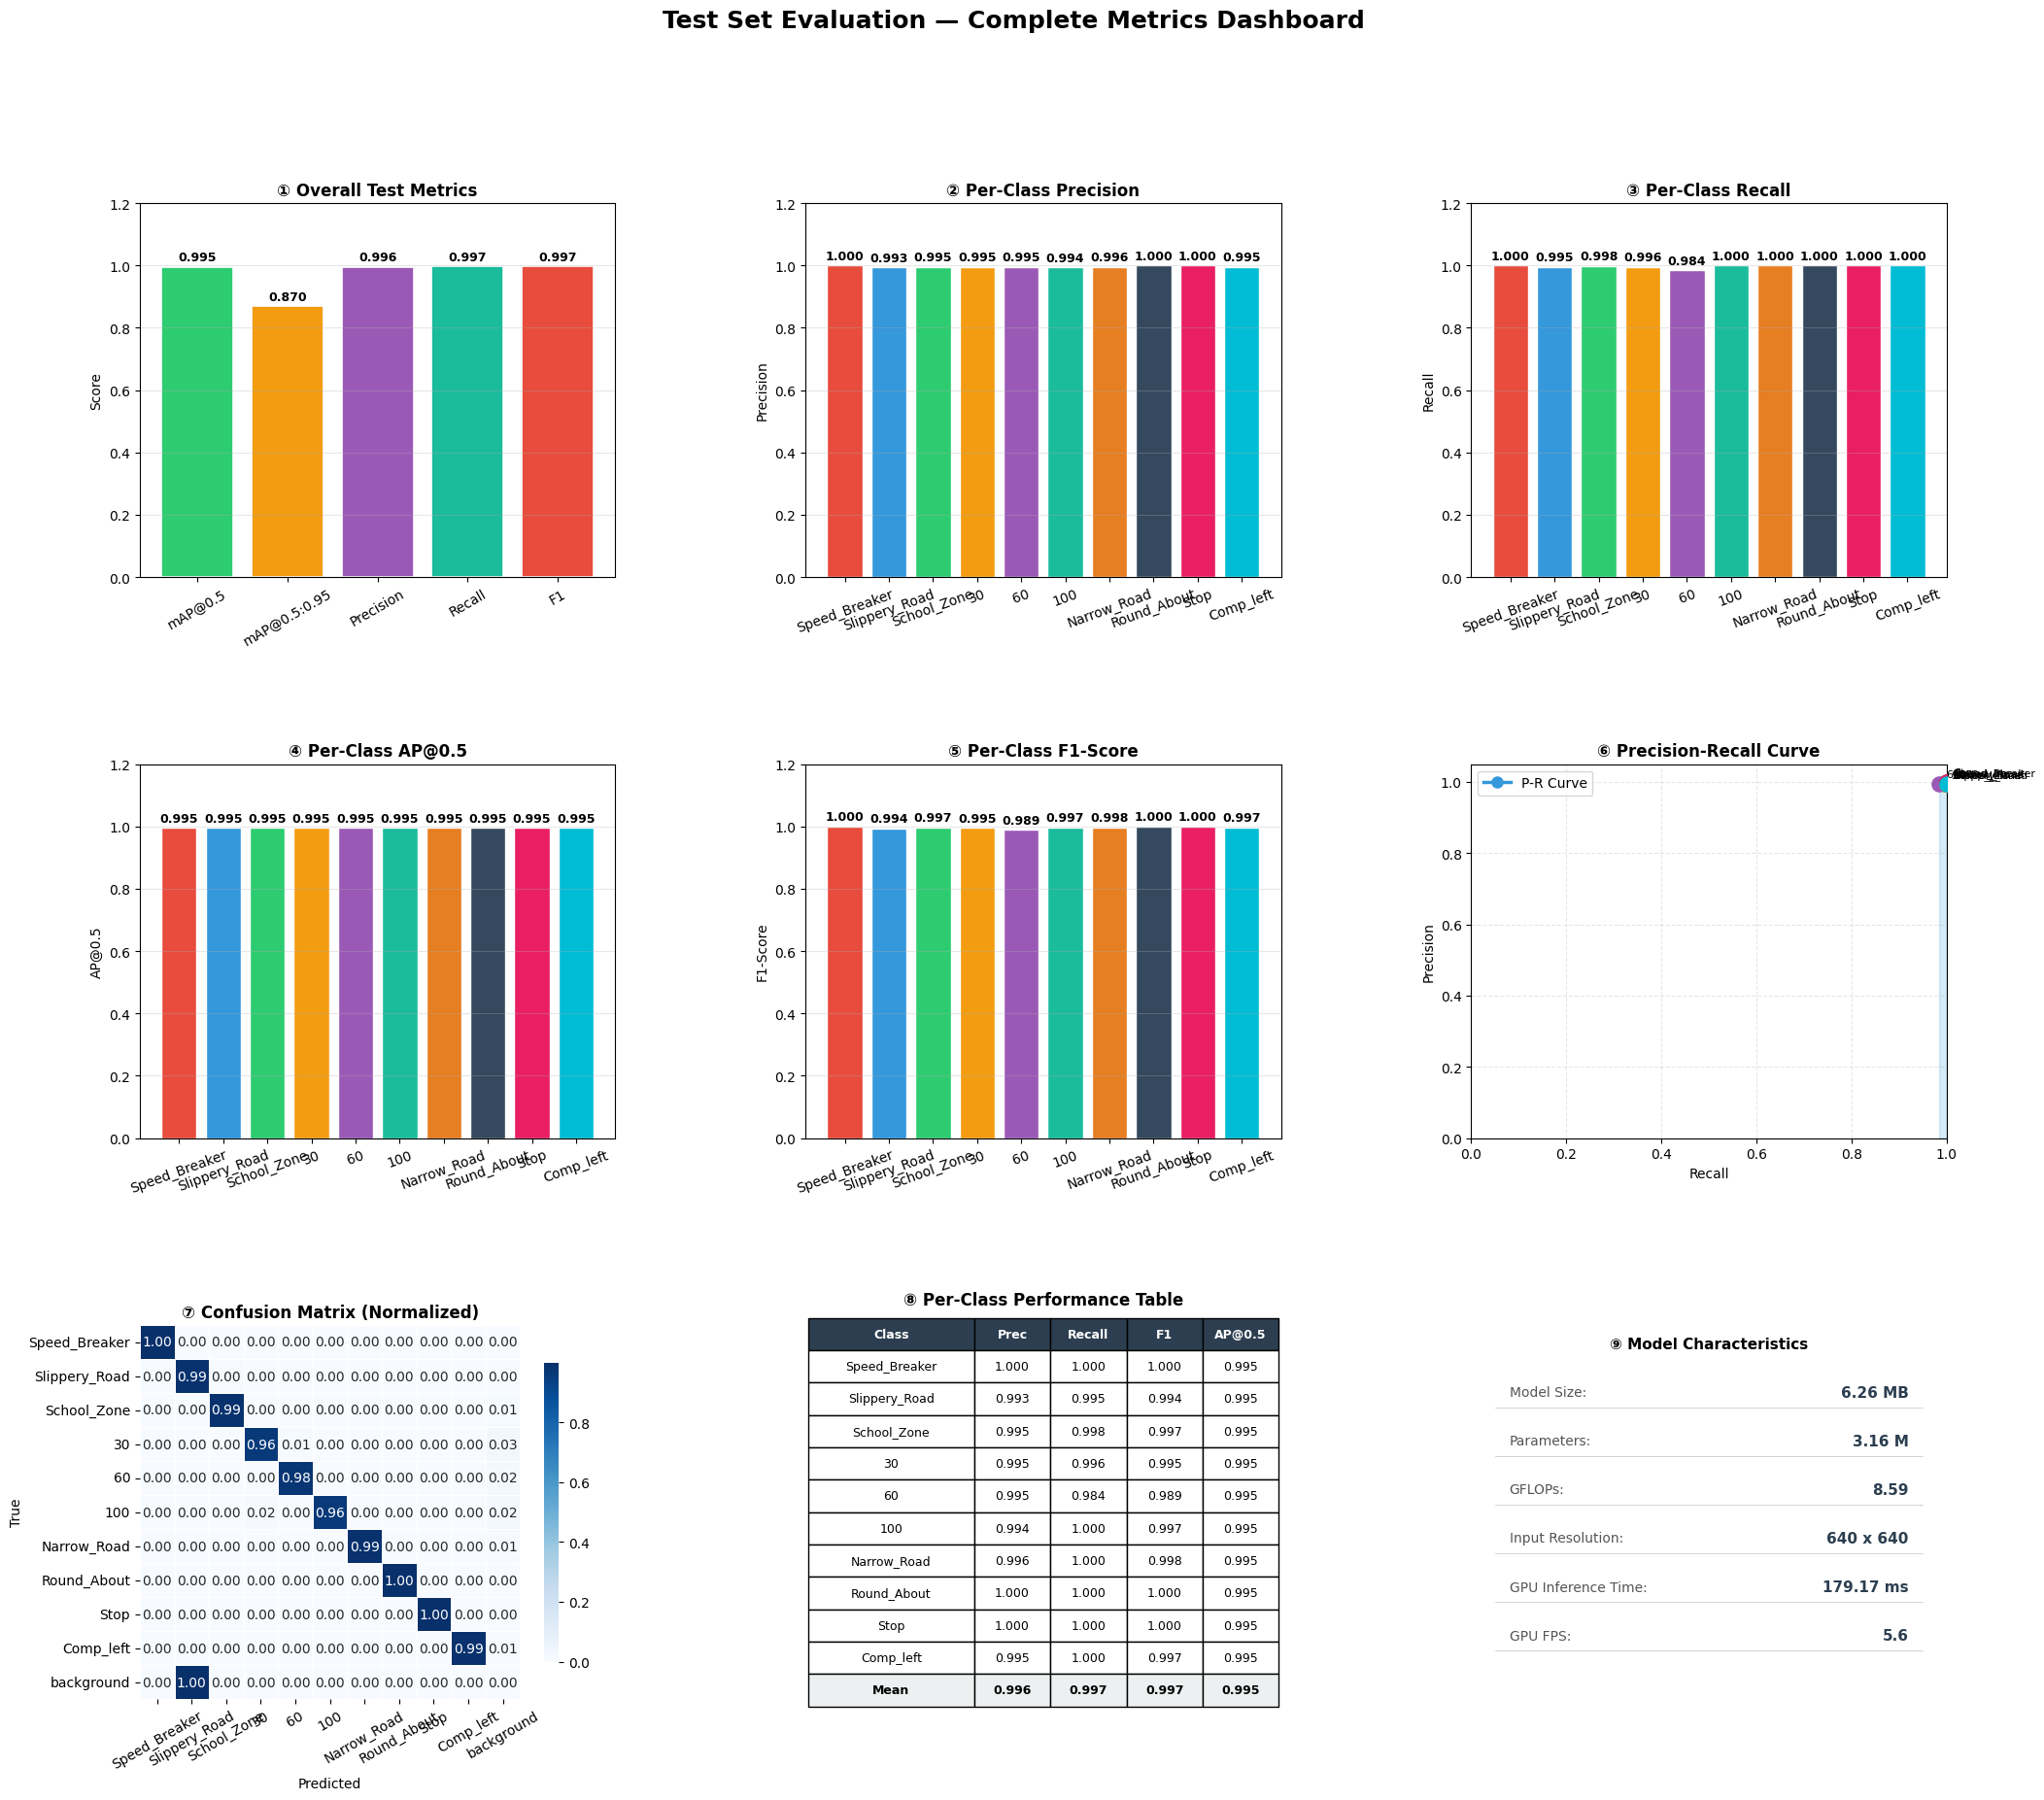

✅ Test metrics dashboard saved!

💾 PART 6: SAVING RESULTS
✅ Per-class CSV saved!
        Class  Precision   Recall  F1-Score   AP@0.5  AP@0.5:0.95
Speed_Breaker   1.000000 1.000000  1.000000 0.995000     0.886115
Slippery_Road   0.993238 0.995261  0.994248 0.994953     0.888228
  School_Zone   0.995298 0.998451  0.996871 0.995000     0.879782
           30   0.994658 0.995618  0.995137 0.994947     0.900973
           60   0.995032 0.983957  0.989463 0.994894     0.874150
          100   0.994391 1.000000  0.997187 0.995000     0.884282
  Narrow_Road   0.995609 1.000000  0.997799 0.995000     0.808140
  Round_About   1.000000 1.000000  1.000000 0.995000     0.853006
         Stop   1.000000 1.000000  1.000000 0.995000     0.864159
    Comp_left   0.994681 1.000000  0.997333 0.995000     0.857710
✅ Overall metrics TXT saved!

🎉 ANALYSIS COMPLETE!

📁 All results saved in: /content/drive/MyDrive/Major_Project/10Classes/FINAL_MODEL_MobileVIT/test_analysis_results/
   ├── training_curves.pn

In [17]:
#from ultralytics import YOLO
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
from pathlib import Path
import pandas as pd
import seaborn as sns
import os
import time
import torch

# ===================== CONFIGURATION =====================
RESULTS_CSV     = "/content/drive/MyDrive/Major_Project/10Classes/FINAL_MODEL_MobileVIT/10class_weights_the final_model/results_mobileVIT_10class.csv"
BEST_MODEL_PATH = "/content/drive/MyDrive/Major_Project/10Classes/FINAL_MODEL_MobileVIT/10class_weights_the final_model/best.pt"
DATA_YAML       = "/content/drive/MyDrive/Major_Project/10Classes/10_class/data.yaml"
TEST_OUTPUT_DIR = "/content/drive/MyDrive/Major_Project/10Classes/FINAL_MODEL_MobileVIT/test_analysis_results"
DATASET_PATH    = "/content/drive/MyDrive/Major_Project/10Classes/10_class"

Path(TEST_OUTPUT_DIR).mkdir(parents=True, exist_ok=True)

print("=" * 100)
print("🎯 YOLO MODEL - COMPLETE ANALYSIS")
print("=" * 100)

# ===================== PART 1: TRAINING HISTORY CURVES =====================
print("\n" + "=" * 100)
print("📊 PART 1: TRAINING HISTORY CURVES")
print("=" * 100)

df = pd.read_csv(RESULTS_CSV)
df.columns = df.columns.str.strip()

epochs            = df['epoch'].values
train_box_loss    = df['train/box_loss'].values
val_box_loss      = df['val/box_loss'].values
train_cls_loss    = df['train/cls_loss'].values  if 'train/cls_loss'  in df.columns else None
val_cls_loss      = df['val/cls_loss'].values    if 'val/cls_loss'    in df.columns else None
train_dfl_loss    = df['train/dfl_loss'].values  if 'train/dfl_loss'  in df.columns else None
val_dfl_loss      = df['val/dfl_loss'].values    if 'val/dfl_loss'    in df.columns else None
map50_history     = df['metrics/mAP50(B)'].values
map5095_history   = df['metrics/mAP50-95(B)'].values
precision_history = df['metrics/precision(B)'].values
recall_history    = df['metrics/recall(B)'].values
f1_history        = 2 * (precision_history * recall_history) / (precision_history + recall_history + 1e-6)

print(f"✅ Loaded {len(epochs)} epochs from results CSV")
print(f"\nTraining Metrics per Epoch:")
print("-" * 100)
print("{:<8} {:<15} {:<15} {:<15} {:<15} {:<15} {:<15}".format(
    "Epoch", "Train Loss", "Val Loss", "mAP@0.5", "mAP@0.5:0.95", "Precision", "Recall"))
print("-" * 100)
for i in range(len(epochs)):
    print("{:<8} {:<15.4f} {:<15.4f} {:<15.4f} {:<15.4f} {:<15.4f} {:<15.4f}".format(
        int(epochs[i]), train_box_loss[i], val_box_loss[i],
        map50_history[i], map5095_history[i], precision_history[i], recall_history[i]))
print("-" * 100)

# ── Plot 1: Training Curves ───────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(20, 11))
fig.suptitle('Training History — Loss & Metric Curves', fontsize=17, fontweight='bold')

def styled_plot(ax, x, y1, y2, label1, label2, color1, color2, title, ylabel):
    ax.plot(x, y1, 'o-', label=label1, linewidth=2.5, markersize=5, color=color1)
    ax.plot(x, y2, 's-', label=label2, linewidth=2.5, markersize=5, color=color2)
    ax.fill_between(x, y1, alpha=0.15, color=color1)
    ax.fill_between(x, y2, alpha=0.15, color=color2)
    ax.set_title(title, fontweight='bold', fontsize=11)
    ax.set_xlabel('Epoch')
    ax.set_ylabel(ylabel)
    ax.legend()
    ax.grid(True, alpha=0.3, linestyle='--')

# Box Loss
styled_plot(axes[0,0], epochs, train_box_loss, val_box_loss,
            'Train Box Loss', 'Val Box Loss', '#e74c3c', '#3498db',
            '① Box Loss (Train vs Val)', 'Loss')

# Cls Loss
if train_cls_loss is not None:
    styled_plot(axes[0,1], epochs, train_cls_loss, val_cls_loss,
                'Train Cls Loss', 'Val Cls Loss', '#e67e22', '#9b59b6',
                '② Classification Loss (Train vs Val)', 'Loss')
else:
    axes[0,1].axis('off')
    axes[0,1].text(0.5, 0.5, 'Cls Loss\nNot Available',
                   ha='center', va='center', fontsize=13)

# DFL Loss
if train_dfl_loss is not None:
    styled_plot(axes[0,2], epochs, train_dfl_loss, val_dfl_loss,
                'Train DFL Loss', 'Val DFL Loss', '#1abc9c', '#f39c12',
                '③ DFL Loss (Train vs Val)', 'Loss')
else:
    axes[0,2].axis('off')
    axes[0,2].text(0.5, 0.5, 'DFL Loss\nNot Available',
                   ha='center', va='center', fontsize=13)

# mAP vs Epoch
ax = axes[1,0]
ax.plot(epochs, map50_history,   'o-', color='#2ecc71', linewidth=2.5, markersize=5, label='mAP@0.5')
ax.plot(epochs, map5095_history, 's-', color='#f39c12', linewidth=2.5, markersize=5, label='mAP@0.5:0.95')
ax.fill_between(epochs, map50_history,   alpha=0.15, color='#2ecc71')
ax.fill_between(epochs, map5095_history, alpha=0.15, color='#f39c12')
ax.set_title('④ mAP vs Epoch', fontweight='bold', fontsize=11)
ax.set_xlabel('Epoch')
ax.set_ylabel('mAP')
ax.set_ylim([0, 1])
ax.legend()
ax.grid(True, alpha=0.3, linestyle='--')

# Precision vs Epoch
ax = axes[1,1]
ax.plot(epochs, precision_history, 'o-', color='#9b59b6', linewidth=2.5, markersize=5)
ax.fill_between(epochs, precision_history, alpha=0.15, color='#9b59b6')
ax.axhline(y=precision_history[-1], color='red', linestyle='--', linewidth=1.5,
           label=f'Final: {precision_history[-1]:.4f}')
ax.set_title('⑤ Precision vs Epoch', fontweight='bold', fontsize=11)
ax.set_xlabel('Epoch')
ax.set_ylabel('Precision')
ax.set_ylim([0, 1])
ax.legend()
ax.grid(True, alpha=0.3, linestyle='--')

# Recall vs Epoch
ax = axes[1,2]
ax.plot(epochs, recall_history, 'o-', color='#1abc9c', linewidth=2.5, markersize=5)
ax.fill_between(epochs, recall_history, alpha=0.15, color='#1abc9c')
ax.axhline(y=recall_history[-1], color='red', linestyle='--', linewidth=1.5,
           label=f'Final: {recall_history[-1]:.4f}')
ax.set_title('⑥ Recall vs Epoch', fontweight='bold', fontsize=11)
ax.set_xlabel('Epoch')
ax.set_ylabel('Recall')
ax.set_ylim([0, 1])
ax.legend()
ax.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig(f'{TEST_OUTPUT_DIR}/training_curves.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"✅ Training curves saved!")

# ===================== PART 2: LOAD MODEL =====================
# ===================== PART 2: LOAD MODEL =====================
print("\n" + "=" * 100)
print("📦 PART 2: LOADING MODEL")
print("=" * 100)

# model is already loaded from the previous cell — skip re-loading
print("✅ Using pre-loaded model with custom_blocks registered.")

# ===================== PART 3: TEST SET EVALUATION =====================
print("\n" + "=" * 100)
print("🧪 PART 3: TEST SET EVALUATION")
print("=" * 100)

test_results = model.val(
    data=DATA_YAML,
    split='test',
    imgsz=640,
    batch=16,
    conf=0.25,
    iou=0.6,
    plots=True,
    save_json=True,
    project=TEST_OUTPUT_DIR,
    name='test_evaluation'
)

# ── Extract Metrics ───────────────────────────────────────────────────────
mp          = float(test_results.box.mp)
mr          = float(test_results.box.mr)
map50       = float(test_results.box.map50)
map5095     = float(test_results.box.map)
f1_overall  = 2 * mp * mr / (mp + mr + 1e-6)

class_names  = list(test_results.names.values())
p_per_class  = test_results.box.p.tolist()
r_per_class  = test_results.box.r.tolist()
ap50_per_cls = test_results.box.ap50.tolist()
ap_per_cls   = test_results.box.ap.tolist()
f1_per_cls   = [2*p*r/(p+r+1e-6) for p,r in zip(p_per_class, r_per_class)]

print(f"\n{'='*60}")
print(f"  mAP@0.5        : {map50:.4f}")
print(f"  mAP@0.5:0.95   : {map5095:.4f}")
print(f"  Precision       : {mp:.4f}")
print(f"  Recall          : {mr:.4f}")
print(f"  F1-Score        : {f1_overall:.4f}")
print(f"{'='*60}")

# ===================== PART 4: MODEL CHARACTERISTICS =====================
print("\n" + "=" * 100)
print("⚙️  PART 4: MODEL CHARACTERISTICS")
print("=" * 100)

# Model Size
model_size_bytes = os.path.getsize(BEST_MODEL_PATH)
model_size_mb    = model_size_bytes / (1024 * 1024)

# Parameters
try:
    total_params = sum(p.numel() for p in model.model.parameters())
except:
    total_params = None

# GFLOPs — correct method
try:
    from ultralytics.utils.torch_utils import get_flops
    gflops = get_flops(model.model)
except:
    try:
        info   = model.info(verbose=False)
        gflops = info[1]
    except:
        gflops = None

print(f"✅ GFLOPs: {gflops:.2f}" if gflops else "⚠️ GFLOPs: Not Available")

# Input Resolution
input_resolution = "640 x 640"

# ── GPU Inference Time & FPS ──────────────────────────────────────────────
gpu_inference_ms = None
gpu_fps          = None

try:
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    print(f"\n  Running inference speed test on: {device.upper()}")

    dummy_input = torch.zeros(1, 3, 640, 640).to(device)
    model_gpu   = model.model.to(device)
    model_gpu.eval()

    # Warmup
    with torch.no_grad():
        for _ in range(10):
            _ = model_gpu(dummy_input)

    # Measure
    times = []
    with torch.no_grad():
        for _ in range(100):
            if device == 'cuda':
                torch.cuda.synchronize()
            t0 = time.perf_counter()
            _ = model_gpu(dummy_input)
            if device == 'cuda':
                torch.cuda.synchronize()
            times.append((time.perf_counter() - t0) * 1000)

    gpu_inference_ms = np.mean(times)
    gpu_fps          = 1000 / gpu_inference_ms

except Exception as e:
    print(f"  ⚠️ Inference speed test failed: {e}")

print(f"\n  Model Size        : {model_size_mb:.2f} MB")
print(f"  Parameters        : {total_params/1e6:.2f} M" if total_params else "  Parameters        : N/A")
print(f"  GFLOPs            : {gflops:.2f}"             if gflops        else "  GFLOPs            : N/A")
print(f"  Input Resolution  : {input_resolution}")
print(f"  GPU Inference Time: {gpu_inference_ms:.2f} ms" if gpu_inference_ms else "  GPU Inference Time: N/A")
print(f"  GPU FPS           : {gpu_fps:.1f}"             if gpu_fps       else "  GPU FPS           : N/A")

# ===================== PART 5: COMPREHENSIVE VISUALIZATIONS =====================
print("\n" + "=" * 100)
print("📊 PART 5: GENERATING VISUALIZATIONS")
print("=" * 100)
base_colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6',
               '#1abc9c', '#e67e22', '#34495e', '#e91e63', '#00bcd4',
               '#8bc34a', '#ff5722', '#607d8b', '#795548', '#673ab7']
colors_cls = (base_colors * ((len(class_names) // len(base_colors)) + 1))[:len(class_names)]

fig = plt.figure(figsize=(24, 20))
fig.suptitle('Test Set Evaluation — Complete Metrics Dashboard', fontsize=18, fontweight='bold')
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.5, wspace=0.4)

# ── 1. Overall Metrics ────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
overall_names  = ['mAP@0.5', 'mAP@0.5:0.95', 'Precision', 'Recall', 'F1']
overall_values = [map50, map5095, mp, mr, f1_overall]
bars = ax1.bar(overall_names, overall_values,
               color=['#2ecc71','#f39c12','#9b59b6','#1abc9c','#e74c3c'],
               edgecolor='white', linewidth=1.2)
for bar, val in zip(bars, overall_values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{val:.3f}', ha='center', fontsize=9, fontweight='bold')
ax1.set_ylim([0, 1.2])
ax1.set_title('① Overall Test Metrics', fontweight='bold')
ax1.set_ylabel('Score')
ax1.tick_params(axis='x', rotation=30)
ax1.grid(True, alpha=0.3, axis='y')

# ── 2. Per-Class Precision ────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
bars = ax2.bar(class_names, p_per_class, color=colors_cls, edgecolor='white')
for bar, val in zip(bars, p_per_class):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{val:.3f}', ha='center', fontsize=9, fontweight='bold')
ax2.set_ylim([0, 1.2])
ax2.set_title('② Per-Class Precision', fontweight='bold')
ax2.set_ylabel('Precision')
ax2.tick_params(axis='x', rotation=20)
ax2.grid(True, alpha=0.3, axis='y')

# ── 3. Per-Class Recall ───────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
bars = ax3.bar(class_names, r_per_class, color=colors_cls, edgecolor='white')
for bar, val in zip(bars, r_per_class):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{val:.3f}', ha='center', fontsize=9, fontweight='bold')
ax3.set_ylim([0, 1.2])
ax3.set_title('③ Per-Class Recall', fontweight='bold')
ax3.set_ylabel('Recall')
ax3.tick_params(axis='x', rotation=20)
ax3.grid(True, alpha=0.3, axis='y')

# ── 4. Per-Class AP@0.5 ───────────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 0])
bars = ax4.bar(class_names, ap50_per_cls, color=colors_cls, edgecolor='white')
for bar, val in zip(bars, ap50_per_cls):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{val:.3f}', ha='center', fontsize=9, fontweight='bold')
ax4.set_ylim([0, 1.2])
ax4.set_title('④ Per-Class AP@0.5', fontweight='bold')
ax4.set_ylabel('AP@0.5')
ax4.tick_params(axis='x', rotation=20)
ax4.grid(True, alpha=0.3, axis='y')

# ── 5. Per-Class F1 ───────────────────────────────────────────────────────
ax5 = fig.add_subplot(gs[1, 1])
bars = ax5.bar(class_names, f1_per_cls, color=colors_cls, edgecolor='white')
for bar, val in zip(bars, f1_per_cls):
    ax5.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{val:.3f}', ha='center', fontsize=9, fontweight='bold')
ax5.set_ylim([0, 1.2])
ax5.set_title('⑤ Per-Class F1-Score', fontweight='bold')
ax5.set_ylabel('F1-Score')
ax5.tick_params(axis='x', rotation=20)
ax5.grid(True, alpha=0.3, axis='y')

# ── 6. Precision-Recall Curve ─────────────────────────────────────────────
ax6 = fig.add_subplot(gs[1, 2])
r_arr    = np.array(r_per_class)
p_arr    = np.array(p_per_class)
sort_idx = np.argsort(r_arr)
ax6.plot(r_arr[sort_idx], p_arr[sort_idx], 'o-', linewidth=2.5,
         markersize=8, color='#3498db', label='P-R Curve')
ax6.fill_between(r_arr[sort_idx], p_arr[sort_idx], alpha=0.2, color='#3498db')
for i, cls in enumerate(class_names):
    ax6.scatter(r_arr[i], p_arr[i], s=120, color=colors_cls[i], zorder=5)
    ax6.annotate(cls, (r_arr[i], p_arr[i]), fontsize=8,
                 xytext=(5, 5), textcoords='offset points')
ax6.set_xlim([0, 1]); ax6.set_ylim([0, 1.05])
ax6.set_xlabel('Recall'); ax6.set_ylabel('Precision')
ax6.set_title('⑥ Precision-Recall Curve', fontweight='bold')
ax6.grid(True, alpha=0.3, linestyle='--')
ax6.legend()

# ── 7. Confusion Matrix ───────────────────────────────────────────────────
ax7 = fig.add_subplot(gs[2, 0])
try:
    cm      = test_results.confusion_matrix.matrix
    cm_norm = cm.astype('float') / (cm.sum(axis=1, keepdims=True) + 1e-6)
    labels  = class_names + ['background']
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=labels, yticklabels=labels, ax=ax7,
                linewidths=0.5, cbar_kws={'shrink': 0.8})
    ax7.set_title('⑦ Confusion Matrix (Normalized)', fontweight='bold')
    ax7.set_xlabel('Predicted'); ax7.set_ylabel('True')
    ax7.tick_params(axis='x', rotation=30)
    ax7.tick_params(axis='y', rotation=0)
except Exception as e:
    ax7.axis('off')
    ax7.text(0.5, 0.5, f'Confusion Matrix\nNot Available',
             ha='center', va='center', fontsize=11)

# ── 8. Per-Class Summary Table ────────────────────────────────────────────
ax8 = fig.add_subplot(gs[2, 1])
ax8.axis('off')
table_data = [['Class', 'Prec', 'Recall', 'F1', 'AP@0.5']]
for i, cls in enumerate(class_names):
    table_data.append([cls,
                        f'{p_per_class[i]:.3f}',
                        f'{r_per_class[i]:.3f}',
                        f'{f1_per_cls[i]:.3f}',
                        f'{ap50_per_cls[i]:.3f}'])
table_data.append(['Mean',
                    f'{mp:.3f}', f'{mr:.3f}',
                    f'{f1_overall:.3f}', f'{map50:.3f}'])

tbl = ax8.table(cellText=table_data, cellLoc='center',
                loc='center', colWidths=[0.35, 0.16, 0.16, 0.16, 0.16])
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1, 2.0)

for j in range(5):
    tbl[(0, j)].set_facecolor('#2c3e50')
    tbl[(0, j)].set_text_props(color='white', fontweight='bold')

last = len(table_data) - 1
for j in range(5):
    tbl[(last, j)].set_facecolor('#ecf0f1')
    tbl[(last, j)].set_text_props(fontweight='bold')

ax8.set_title('⑧ Per-Class Performance Table', fontweight='bold', pad=15)

# ── 9. Model Characteristics Panel ───────────────────────────────────────
ax9 = fig.add_subplot(gs[2, 2])
ax9.axis('off')

char_lines = [
    ("Model Size",         f"{model_size_mb:.2f} MB"),
    ("Parameters",         f"{total_params/1e6:.2f} M" if total_params else "N/A"),
    ("GFLOPs",             f"{gflops:.2f}"             if gflops        else "N/A"),
    ("Input Resolution",   input_resolution),
    ("GPU Inference Time", f"{gpu_inference_ms:.2f} ms" if gpu_inference_ms else "N/A"),
    ("GPU FPS",            f"{gpu_fps:.1f}"             if gpu_fps       else "N/A"),
]

ax9.text(0.5, 0.97, '⑨ Model Characteristics',
         ha='center', va='top', fontsize=11, fontweight='bold',
         transform=ax9.transAxes)

for idx, (label, value) in enumerate(char_lines):
    y_pos = 0.82 - idx * 0.13
    ax9.text(0.08, y_pos, f"{label}:", ha='left', va='center',
             fontsize=10, color='#555555', transform=ax9.transAxes)
    ax9.text(0.92, y_pos, value, ha='right', va='center',
             fontsize=11, fontweight='bold', color='#2c3e50',
             transform=ax9.transAxes)
    ax9.plot([0.05, 0.95], [y_pos - 0.04, y_pos - 0.04],
             color='#bdc3c7', linewidth=0.5, transform=ax9.transAxes)

plt.savefig(f'{TEST_OUTPUT_DIR}/test_metrics_dashboard.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"✅ Test metrics dashboard saved!")

# ===================== PART 6: SAVE CSV & TXT RESULTS =====================
print("\n" + "=" * 100)
print("💾 PART 6: SAVING RESULTS")
print("=" * 100)

# Per-class CSV
df_cls = pd.DataFrame({
    'Class':     class_names,
    'Precision': p_per_class,
    'Recall':    r_per_class,
    'F1-Score':  f1_per_cls,
    'AP@0.5':    ap50_per_cls,
    'AP@0.5:0.95': ap_per_cls,
})
df_cls.to_csv(f'{TEST_OUTPUT_DIR}/per_class_metrics.csv', index=False)
print(f"✅ Per-class CSV saved!")
print(df_cls.to_string(index=False))

# Overall TXT
with open(f'{TEST_OUTPUT_DIR}/overall_metrics.txt', 'w') as f:
    f.write("=" * 70 + "\n")
    f.write("YOLO MODEL — COMPLETE EVALUATION RESULTS\n")
    f.write("=" * 70 + "\n\n")
    f.write("TEST SET PERFORMANCE:\n")
    f.write(f"  mAP@0.5           : {map50:.4f}\n")
    f.write(f"  mAP@0.5:0.95      : {map5095:.4f}\n")
    f.write(f"  Precision         : {mp:.4f}\n")
    f.write(f"  Recall            : {mr:.4f}\n")
    f.write(f"  F1-Score          : {f1_overall:.4f}\n\n")
    f.write("MODEL CHARACTERISTICS:\n")
    f.write(f"  Model Size        : {model_size_mb:.2f} MB\n")
    f.write(f"  Parameters        : {total_params/1e6:.2f} M\n" if total_params else "  Parameters        : N/A\n")
    f.write(f"  GFLOPs            : {gflops:.2f}\n"             if gflops        else "  GFLOPs            : N/A\n")
    f.write(f"  Input Resolution  : {input_resolution}\n")
    f.write(f"  GPU Inference Time: {gpu_inference_ms:.2f} ms\n" if gpu_inference_ms else "  GPU Inference Time: N/A\n")
    f.write(f"  GPU FPS           : {gpu_fps:.1f}\n"             if gpu_fps       else "  GPU FPS           : N/A\n")
    f.write("\nTRAINING HISTORY (Final Epoch):\n")
    f.write(f"  Train Box Loss    : {train_box_loss[-1]:.4f}\n")
    f.write(f"  Val Box Loss      : {val_box_loss[-1]:.4f}\n")
    f.write(f"  Final mAP@0.5     : {map50_history[-1]:.4f}\n")
    f.write(f"  Final Precision   : {precision_history[-1]:.4f}\n")
    f.write(f"  Final Recall      : {recall_history[-1]:.4f}\n")
    f.write("=" * 70 + "\n")

print(f"✅ Overall metrics TXT saved!")

# ===================== FINAL SUMMARY =====================
print("\n" + "=" * 100)
print("🎉 ANALYSIS COMPLETE!")
print("=" * 100)
print(f"\n📁 All results saved in: {TEST_OUTPUT_DIR}/")
print(f"   ├── training_curves.png         — Loss & metric curves per epoch")
print(f"   ├── test_metrics_dashboard.png  — Full test evaluation dashboard")
print(f"   ├── per_class_metrics.csv       — Per-class breakdown")
print(f"   ├── overall_metrics.txt         — All metrics summary")
print(f"   └── test_evaluation/            — YOLO raw outputs & confusion matrix")
print(f"\n✨ Key Results:")
print(f"   mAP@0.5        : {map50:.4f}")
print(f"   mAP@0.5:0.95   : {map5095:.4f}")
print(f"   Precision       : {mp:.4f}")
print(f"   Recall          : {mr:.4f}")
print(f"   F1-Score        : {f1_overall:.4f}")
print(f"   Model Size      : {model_size_mb:.2f} MB")
if gpu_inference_ms:
    print(f"   GPU Inference   : {gpu_inference_ms:.2f} ms  |  {gpu_fps:.1f} FPS")
print("=" * 100)

In [2]:
import yaml
from pathlib import Path

OUT = '/content/drive/MyDrive/Major_Project/10Classes/10_class'   # keep same folder or rename if you prefer

CLASS_NAMES = list(range(10))  # [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

data_yaml = {
    'path' : OUT,
    'train': 'images/train',
    'val'  : 'images/val',
    'test' : 'images/test',
    'nc'   : len(CLASS_NAMES),           # 10
    'names': [str(c) for c in CLASS_NAMES],
}

yaml_path = Path(OUT) / 'data.yaml'
with open(yaml_path, 'w') as f:
    yaml.dump(data_yaml, f, default_flow_style=False, sort_keys=False)

print(f'📝 data.yaml created → {yaml_path}\n')
print("─"*30)
with open(yaml_path) as f:
    print(f.read())
print("─"*30)

📝 data.yaml created → /content/drive/MyDrive/Major_Project/10Classes/10_class/data.yaml

──────────────────────────────
path: /content/drive/MyDrive/Major_Project/10Classes/10_class
train: images/train
val: images/val
test: images/test
nc: 10
names:
- '0'
- '1'
- '2'
- '3'
- '4'
- '5'
- '6'
- '7'
- '8'
- '9'

──────────────────────────────
